In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [ ]:
yes_no_colors = ['#FF6E6E', '#7EFD5E']
background_color = '#041744'


fill_color = "#491bbf"
font_style = 'serif'
font_color = '#FDE2FF'

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['axes.labelcolor'] = font_color
plt.rcParams['axes.edgecolor'] = font_color
plt.rcParams['font.family'] = font_style
plt.rcParams['text.color'] = font_color
plt.rcParams['xtick.color'] = font_color
plt.rcParams['ytick.color'] = font_color

### Считали данные

In [ ]:
import zipfile

# Путь к загруженному архиву
zip_path = '/content/teta-ml-2-2025.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [ ]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [ ]:
print(df_train.shape)
print(df_test.shape)

(36671, 15)
(12224, 14)


In [ ]:
df_train.head(5)

,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155


In [ ]:
df_train.isna().sum()

,0
name,9
_id,0
host_name,18
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0


In [ ]:
df_test.isna().sum()

,0
name,7
_id,0
host_name,3
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36671 entries, 0 to 36670
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              36662 non-null  object 
 1   _id               36671 non-null  int64  
 2   host_name         36653 non-null  object 
 3   location_cluster  36671 non-null  object 
 4   location          36671 non-null  object 
 5   lat               36671 non-null  float64
 6   lon               36671 non-null  float64
 7   type_house        36671 non-null  object 
 8   sum               36671 non-null  int64  
 9   min_days          36671 non-null  int64  
 10  amt_reviews       36671 non-null  int64  
 11  last_dt           29169 non-null  object 
 12  avg_reviews       29169 non-null  float64
 13  total_host        36671 non-null  int64  
 14  target            36671 non-null  int64  
dtypes: float64(3), int64(6), object(6)
memory usage: 4.2+ MB


# Начинаем  обработку

In [ ]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index(['name', 'host_name', 'location_cluster', 'location', 'type_house',
       'last_dt'],
      dtype='object')

In [ ]:
df_train.drop(columns=['name'], inplace=True, errors='ignore')
df_test.drop(columns=['name'], inplace=True, errors='ignore')

In [ ]:
numerical_columns = df_train.select_dtypes(include=['int64', 'float64']).columns
numerical_columns

Index(['_id', 'lat', 'lon', 'sum', 'min_days', 'amt_reviews', 'avg_reviews',
       'total_host', 'target'],
      dtype='object')

In [ ]:
df_train['target'].min()

0

<Axes: xlabel='target', ylabel='Density'>

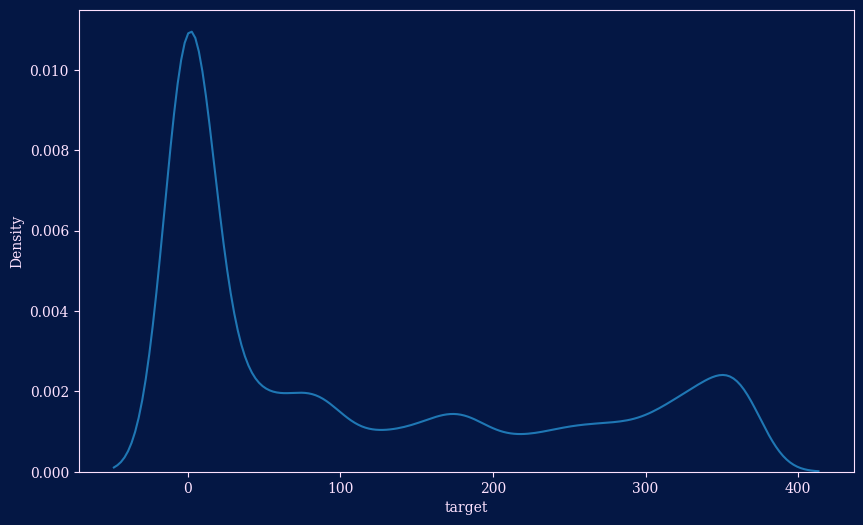

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['target'])

In [ ]:
types_house = df_train['type_house'].unique()
types_house

array(['Entire home/apt', 'Shared room', 'Private room'], dtype=object)

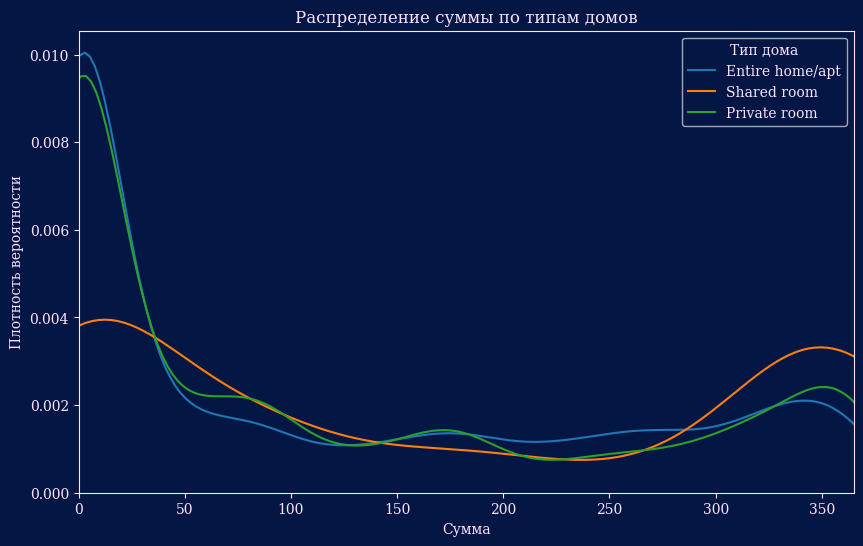

In [ ]:
plt.figure(figsize=(10, 6))

for house_type in types_house:
    sns.kdeplot(df_train[df_train['type_house'] == house_type]['target'], label=house_type)

plt.title('Распределение суммы по типам домов')
plt.xlim(0, df_train['target'].max())
plt.xlabel('Сумма')
plt.ylabel('Плотность вероятности')
plt.legend(title='Тип дома')
plt.show()

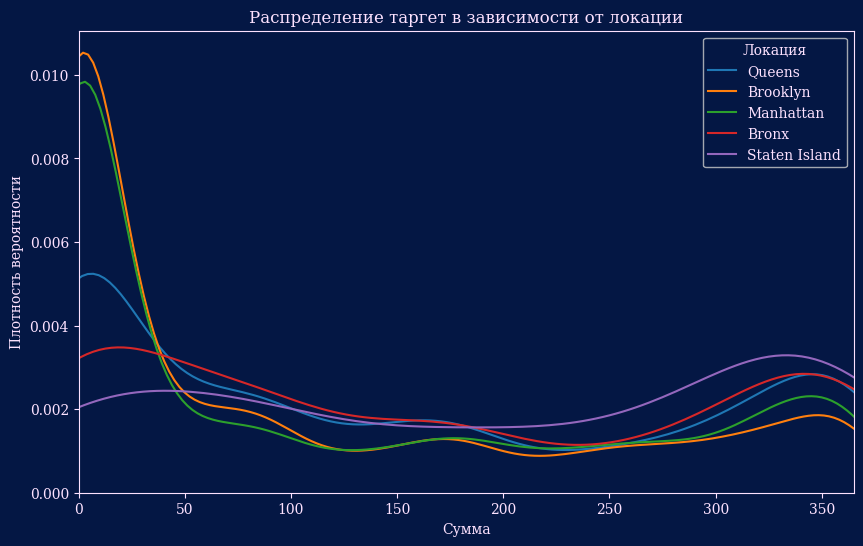

In [ ]:
plt.figure(figsize=(10, 6))

clusters = df_train['location_cluster'].unique()
for cluster in clusters:
    sns.kdeplot(df_train[df_train['location_cluster'] == cluster]['target'], label=cluster)

plt.title('Распределение таргет в зависимости от локации')
plt.xlim(0, df_train['target'].max())
plt.xlabel('Сумма')
plt.ylabel('Плотность вероятности')
plt.legend(title='Локация')
plt.show()

In [ ]:
df_train.columns

Index(['_id', 'host_name', 'location_cluster', 'location', 'lat', 'lon',
       'type_house', 'sum', 'min_days', 'amt_reviews', 'last_dt',
       'avg_reviews', 'total_host', 'target'],
      dtype='object')

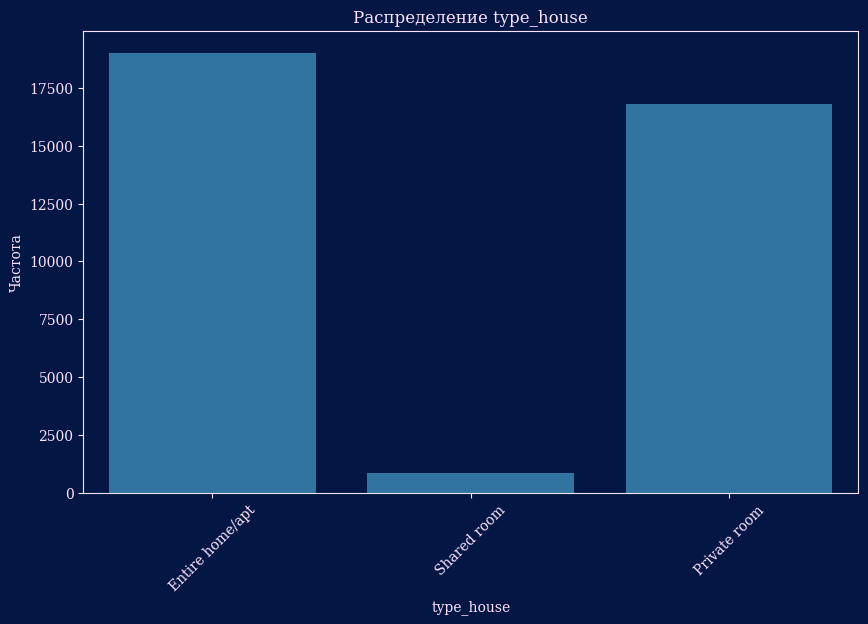

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='type_house',)
plt.xticks(rotation=45)
plt.title('Распределение type_house')
plt.xlabel('type_house')
plt.ylabel('Частота')
plt.show()


#### Развлекаемся с пропусками отзывов

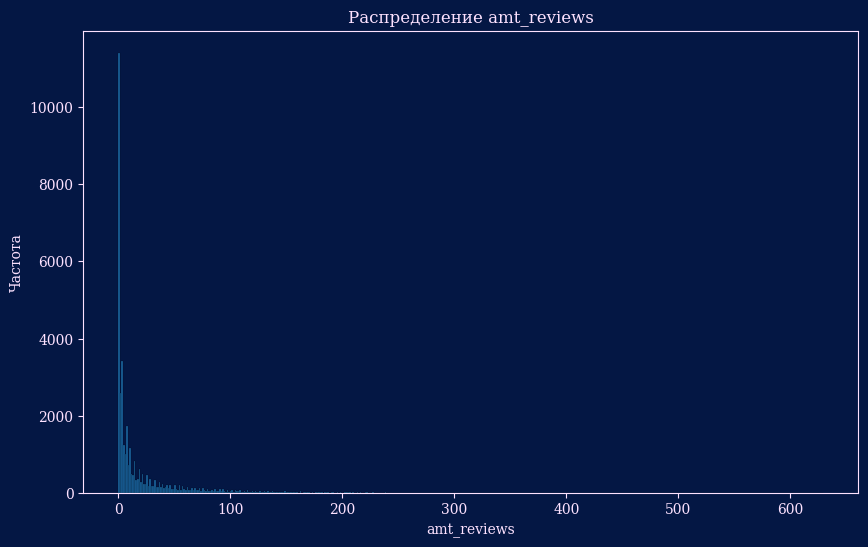

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['amt_reviews'])
plt.title('Распределение amt_reviews')
plt.xlabel('amt_reviews')
plt.ylabel('Частота')
plt.show()

In [ ]:
df_train['avg_reviews'] = df_train.apply(
    lambda row: 0 if (pd.isna(row['avg_reviews']) and row['amt_reviews'] == 0) else row['avg_reviews'], axis=1)

df_test['avg_reviews'] = df_test.apply(
    lambda row: 0 if (pd.isna(row['avg_reviews']) and row['amt_reviews'] == 0) else row['avg_reviews'], axis=1)


In [ ]:
df_test.isna().sum()

,0
_id,0
host_name,3
location_cluster,0
location,0
lat,0
lon,0
type_house,0
sum,0
min_days,0
amt_reviews,0


вышло просто бомбезно

#### Пропуски даты

In [ ]:
missed_last_dt = df_train[df_train['last_dt'].isna()]
missed_last_dt

,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
2,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,0.0,1,0
8,19529891,Shilpa,Manhattan,Upper East Side,40.76870,-73.95560,Entire home/apt,135,3,0,NaN,0.0,1,0
16,1818225,Amael,Brooklyn,Greenpoint,40.72212,-73.93780,Entire home/apt,80,3,0,NaN,0.0,1,0
22,156114168,Kateryna,Brooklyn,Prospect-Lefferts Gardens,40.66049,-73.96162,Shared room,40,1,0,NaN,0.0,6,211
28,146944,David,Manhattan,East Village,40.72807,-73.98594,Entire home/apt,200,3,0,NaN,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36651,200380610,Pranjal,Manhattan,Midtown,40.75237,-73.97040,Entire home/apt,190,30,0,NaN,0.0,65,364
36652,157056254,Rae,Brooklyn,Bushwick,40.70312,-73.91933,Private room,45,7,0,NaN,0.0,1,0
36653,2676750,Shayna,Manhattan,Financial District,40.70789,-74.01521,Private room,90,3,0,NaN,0.0,1,0
36658,24298733,Tuva,Brooklyn,Kensington,40.63670,-73.97434,Private room,35,4,0,NaN,0.0,2,0


In [ ]:
df_train['visited'] = df_train['amt_reviews'].apply(lambda x: 1 if x > 0 else 0)
df_test['visited'] = df_test['amt_reviews'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df_train.drop(columns=['last_dt'], inplace=True, errors='ignore')
df_test.drop(columns=['last_dt'], inplace=True, errors='ignore')

#### Пропуски имени

In [ ]:
missing_host_names = df_train[df_train['host_name'].isna()]
missing_host_names

,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target,visited
573,159156636,NaN,Manhattan,Hell's Kitchen,40.75835,-73.99065,Private room,120,1,88,4.93,3,0,1
2555,39608626,NaN,Manhattan,Harlem,40.82929,-73.94182,Private room,28,1,1,0.02,1,0,1
11741,23077718,NaN,Brooklyn,Crown Heights,40.67512,-73.96146,Private room,50,1,0,0.00,1,0,0
12951,100971588,NaN,Bronx,Highbridge,40.83844,-73.92489,Entire home/apt,75,4,37,1.21,1,26,1
15121,526653,NaN,Queens,Queens Village,40.72413,-73.76133,Private room,50,1,43,0.45,1,88,1
16776,24576978,NaN,Brooklyn,Greenpoint,40.72035,-73.95355,Entire home/apt,195,1,1,0.02,1,0,1
17275,7822683,NaN,Brooklyn,Greenpoint,40.73539,-73.95838,Private room,55,10,2,0.05,1,0,1
18839,7779204,NaN,Brooklyn,Flatbush,40.64965,-73.96154,Entire home/apt,100,30,49,0.69,1,342,1
19104,228750026,NaN,Brooklyn,Flatbush,40.65152,-73.95271,Private room,55,7,0,0.00,1,69,0
21937,26138712,NaN,Queens,Ditmars Steinway,40.77587,-73.91775,Private room,45,1,5,0.13,1,0,1


In [ ]:
df_train['host_name'] = df_train.groupby(['location', 'type_house'])['host_name'].transform(lambda x: x.fillna(x.mode()[0]))
df_test['host_name'] = df_test.groupby(['location', 'type_house'])['host_name'].transform(lambda x: x.fillna(x.mode()[0]))

### Оценим как у нас сумма и таргет себя ведут

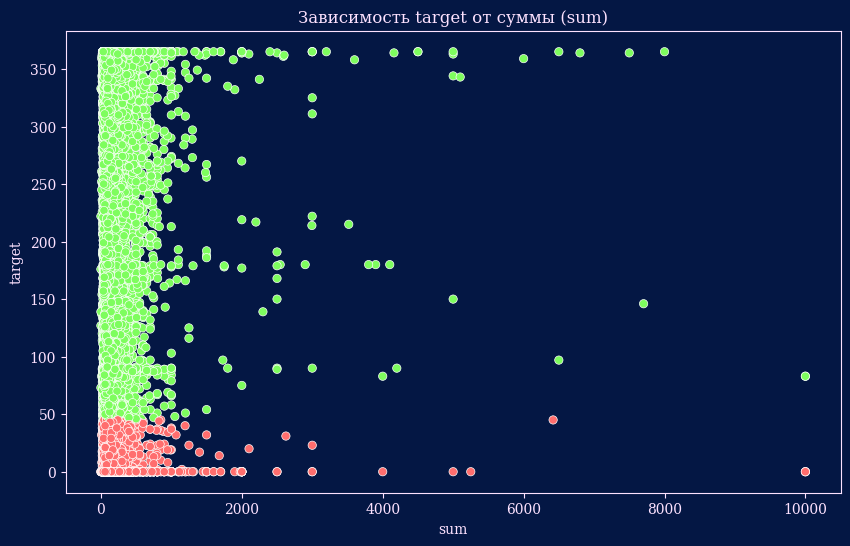

In [ ]:

df_train['target_group'] = df_train['target'].apply(lambda x: 1 if x > df_train['target'].median() else 0)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='sum', y='target', hue='target_group', palette=yes_no_colors, legend=False)
plt.title('Зависимость target от суммы (sum)')
plt.xlabel('sum')
plt.ylabel('target')
plt.show()


In [ ]:
df_train.drop(columns=['target_group'], inplace=True, errors='ignore')

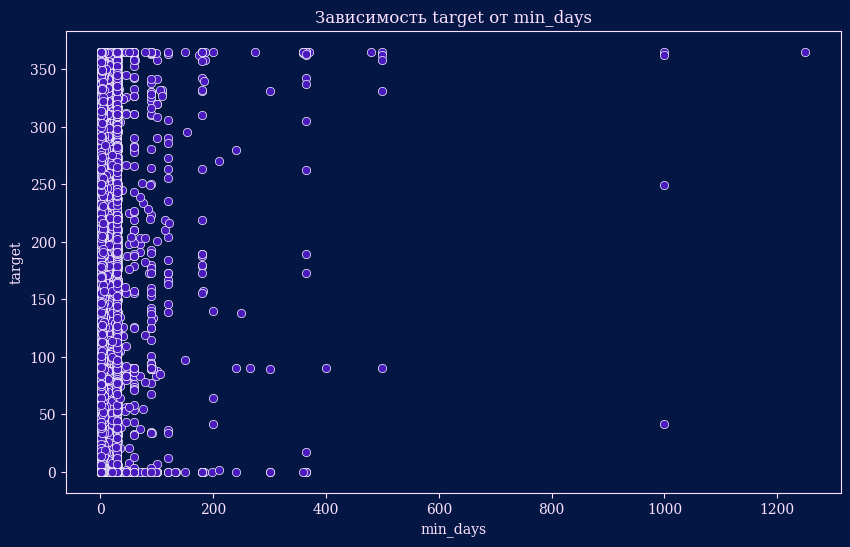

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='min_days', y='target', color=fill_color)
plt.title('Зависимость target от min_days')
plt.xlabel('min_days')
plt.ylabel('target')
plt.show()

### Отскейлим некоторые

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_train[['sum', 'min_days', 'amt_reviews', 'avg_reviews']] = scaler.fit_transform(
    df_train[['sum', 'min_days', 'amt_reviews', 'avg_reviews']]
)


df_test[['sum', 'min_days', 'amt_reviews', 'avg_reviews',]] = scaler.fit_transform(
    df_test[['sum', 'min_days', 'amt_reviews', 'avg_reviews']]
)

In [ ]:
df_train_new = df_train.copy()
df_test_new = df_test.copy()

# Обучаем модели

In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold


### Предобработка для других моделей

In [ ]:
df_train.head()

,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target,visited
0,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,0.827494,-0.234603,-0.412359,1.145268,1,334,1
1,13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,-0.469009,-0.095322,-0.345249,-0.610526,1,0,1
2,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,0.200154,-0.095322,-0.524208,-0.693527,1,0,0
3,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,-0.364452,-0.234603,-0.121550,-0.284906,1,0,1
4,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,-0.222255,-0.234603,0.057409,-0.208289,1,155,1


In [ ]:
to_cat_encode = ['location', 'location_cluster', 'host_name', 'type_house']

In [ ]:
!pip install category-encoders

In [ ]:
import category_encoders as ce


target_enc = ce.CatBoostEncoder(cols=to_cat_encode)

target_enc = target_enc.fit(df_train[to_cat_encode], df_train['target'])

train_encoded = target_enc.transform(df_train[to_cat_encode]).add_suffix('_cb')
test_encoded = target_enc.transform(df_test[to_cat_encode]).add_suffix('_cb')


df_train = df_train.join(train_encoded)
df_test = df_test.join(test_encoded)

df_train.drop(columns=to_cat_encode, inplace=True)
df_test.drop(columns=to_cat_encode, inplace=True)

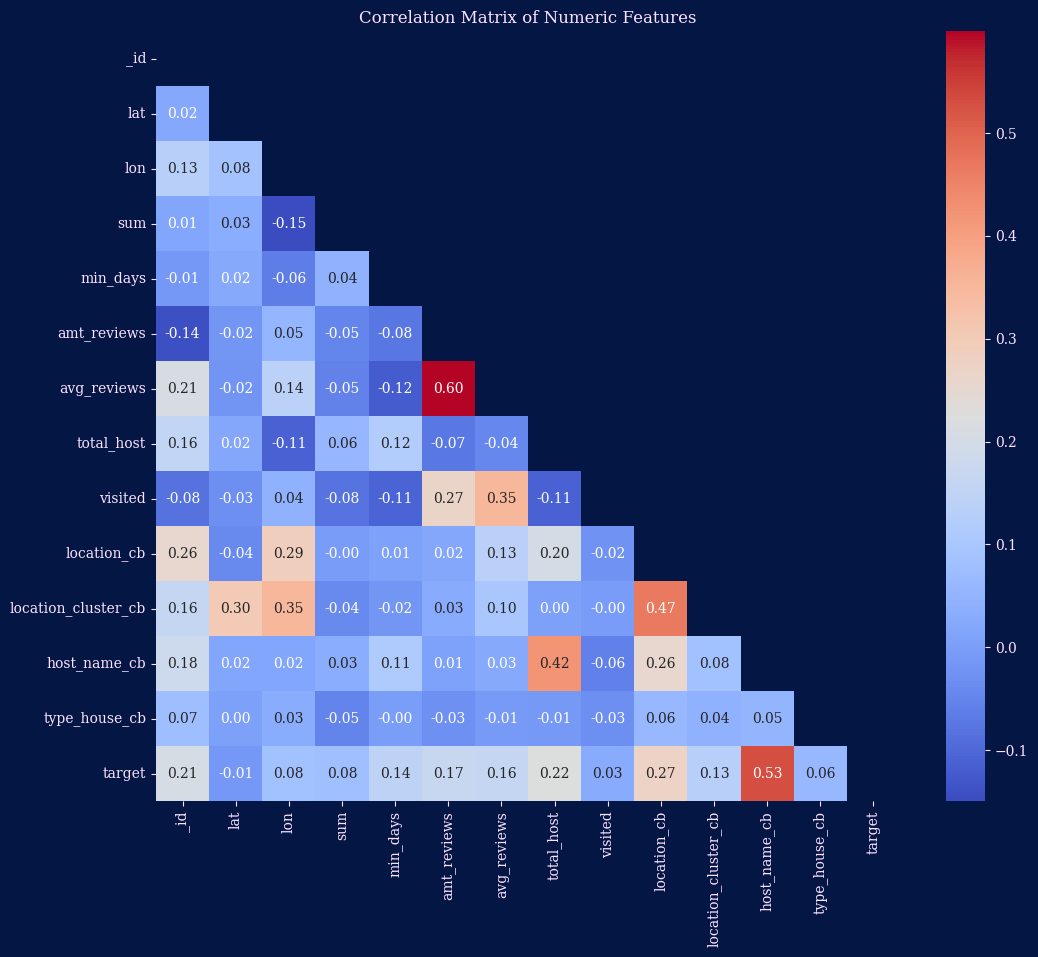

In [ ]:
df_train_copy = df_train.copy()
cols = [col for col in df_train_copy.columns if col != 'target'] + ['target']
df_train_copy = df_train_copy[cols]
numerical_columns = df_train_copy.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_train_copy[numerical_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", mask = np.triu(correlation_matrix))
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [ ]:
features = ['min_days', 'amt_reviews', 'sum', 'total_host', 'location_cb', 'host_name_cb', 'target']

In [ ]:
df_train = df_train[features]
df_test = df_test[features[:-1]]

In [ ]:
df_train.head()

,min_days,amt_reviews,sum,total_host,location_cb,host_name_cb,target
0,-0.234603,-0.412359,0.827494,1,253.922209,151.922209,334
1,-0.095322,-0.345249,-0.469009,1,95.670728,112.766628,0
2,-0.095322,-0.524208,0.200154,1,96.371425,108.192261,0
3,-0.234603,-0.121550,-0.364452,1,108.371826,68.961105,0
4,-0.234603,0.057409,-0.222255,1,95.307485,119.330740,155


In [ ]:
df_test.head()

,min_days,amt_reviews,sum,total_host,location_cb,host_name_cb
0,-0.349477,-0.517112,1.005290,5,104.313663,70.626188
1,-0.349477,-0.426378,-0.458181,3,114.502092,161.953326
2,1.350907,-0.471745,0.495542,121,139.540475,261.936394
3,-0.232209,-0.517112,-0.470513,2,74.942586,89.463754
4,-0.173575,-0.494429,-0.408850,1,93.761464,169.529625


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_train.drop(columns=['target']), df_train['target'], test_size=0.2, random_state=42)

### RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth = 15,
    min_samples_split = 0.0213,
    min_samples_leaf = 0.01,
    random_state=42
)



In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=0.01,
                      min_samples_split=0.0213, n_estimators=300,
                      random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for train_index, val_index in kf.split(X_train, y_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]


    rf_model.fit(X_train_cv, y_train_cv)


    val_preds = rf_model.predict(X_val_cv)
    val_score = mean_squared_error(y_val_cv, val_preds)
    cv_scores.append(val_score)


print(f"Средний MSE для RandomForestRegressor: {np.mean(cv_scores)}")

Средний MSE для RandomForestRegressor: 10269.334375672475


In [ ]:
y_pred_rf = rf_model.predict(X_test)


mse_rf = mean_squared_error(y_test, y_pred_rf)
print("Среднеквадратичная ошибка (MSE) RandomForest:", mse_rf)

Среднеквадратичная ошибка (MSE) RandomForest: 10393.2423167916


### LGBMRegressor

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
import numpy as np

In [ ]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    min_data_in_leaf=30,
    num_leaves=31,
    lambda_l1=0.1,
    lambda_l2=0.1,
    bagging_fraction=0.8,
    bagging_freq=5
)


In [ ]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, lambda_l1=0.1,
              lambda_l2=0.1, learning_rate=0.05, max_depth=5,
              min_data_in_leaf=30, random_state=42)

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train, y_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]
    lgb_model.fit(X_train_cv, y_train_cv)
    val_preds = lgb_model.predict(X_val_cv)
    val_score = mean_squared_error(y_val_cv, val_preds)
    cv_scores.append(val_score)

print(f"Средний MSE для LGBMRegressor с кросс-валидацией: {np.mean(cv_scores)}")

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM

In [ ]:
y_pred_lgb = lgb_model.predict(X_test)


mse_lgb = mean_squared_error(y_test, y_pred_lgb)
print("Среднеквадратичная ошибка (MSE) LGBM:", mse_lgb)

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
Среднеквадратичная ошибка (MSE) LGBM: 9886.28662687956


### SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=88,
    epsilon=0.1419,
    gamma='auto',
    tol=1e-5
)


In [ ]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train, y_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

    svr_model.fit(X_train_cv, y_train_cv)
    val_preds = svr_model.predict(X_val_cv)

    val_score = mean_squared_error(y_val_cv, val_preds)
    cv_scores.append(val_score)

print(f"Средний MSE для SVR с кросс-валидацией: {np.mean(cv_scores)}")

Средний MSE для SVR с кросс-валидацией: 11990.786391259768


In [ ]:
y_pred_svr = svr_model.predict(X_test)


mse_svr = mean_squared_error(y_test, y_pred_svr)
print("Среднеквадратичная ошибка (MSE) SVR:", mse_svr)

Среднеквадратичная ошибка (MSE) SVR: 12269.13791316885


### BayesianRidge

In [ ]:
from sklearn.linear_model import BayesianRidge


In [ ]:
bayes_model = BayesianRidge()


bayes_model.fit(X_train, y_train)

BayesianRidge()

In [ ]:
bayes_model = BayesianRidge(
    alpha_1=1e-5,
    alpha_2=1e-5,
    lambda_1=1e-5,
    lambda_2=1e-5,
)

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, val_index in kf.split(X_train, y_train):
    X_train_cv, X_val_cv = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_cv, y_val_cv = y_train.iloc[train_index], y_train.iloc[val_index]

    bayes_model.fit(X_train_cv, y_train_cv)
    val_preds = bayes_model.predict(X_val_cv)

    val_score = mean_squared_error(y_val_cv, val_preds)
    cv_scores.append(val_score)

print(f"Средний MSE для Bayes с кросс-валидацией: {np.mean(cv_scores)}")

Средний MSE для Bayes с кросс-валидацией: 11383.287052925813


In [ ]:
y_pred_bayes = bayes_model.predict(X_test)


mse_svr = mean_squared_error(y_test, y_pred_bayes)
print("Среднеквадратичная ошибка (MSE) Bayes:", mse_svr)

Среднеквадратичная ошибка (MSE) Bayes: 11453.027928094234


### Catboost

In [ ]:
!pip install catboost -U numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 53.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
from catboost import CatBoostRegressor, Pool

In [ ]:
catboost_model = CatBoostRegressor(
    iterations=1750,
    depth=5,
    learning_rate=0.037,
    max_bin = 250,
    loss_function='RMSE',
    verbose=200
)

In [ ]:
catboost_model.fit(X_train, y_train)

0:	learn: 129.6616457	total: 17.5ms	remaining: 30.6s
200:	learn: 98.9392404	total: 2s	remaining: 15.4s
400:	learn: 97.7080383	total: 3.2s	remaining: 10.8s
600:	learn: 96.7181036	total: 4.03s	remaining: 7.7s
800:	learn: 95.9652785	total: 4.86s	remaining: 5.76s
1000:	learn: 95.3039394	total: 5.68s	remaining: 4.25s
1200:	learn: 94.7530562	total: 6.48s	remaining: 2.96s
1400:	learn: 94.2582959	total: 7.28s	remaining: 1.81s
1600:	learn: 93.8031327	total: 8.09s	remaining: 753ms
1749:	learn: 93.4794751	total: 8.7s	remaining: 0us


In [ ]:
y_pred_cb = catboost_model.predict(X_test)


mse_cb = mean_squared_error(y_test, y_pred_cb)
print("Среднеквадратичная ошибка (MSE) CatBoostRegressor:", mse_cb)

Среднеквадратичная ошибка (MSE) CatBoostRegressor: 9681.543489145162


## Стекинг

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
base_models={
    "rf": rf_model,
    "lgb": lgb_model,
    'bayes': bayes_model,
    'cb': catboost_model,
    'svr': svr_model,
    # 'linreg': LinearRegression()
}

In [ ]:
y_train = df_train['target']
X_train = df_train.drop(['target'], axis=1)

In [ ]:
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



n_test = len(df_test)
preds = np.zeros((len(X_train), len(base_models)))
test_preds = np.zeros((5, 5, n_test))


for model_idx, (model_name, model) in enumerate(base_models.items()):
    temp_oof = np.zeros(len(X_train))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model_fold = clone(model)
        model_fold.fit(X_tr, y_tr)

        val_pred = model_fold.predict(X_val)
        temp_oof[val_idx] = val_pred
        test_preds[model_idx, fold, :] = model_fold.predict(df_test)

    preds[:, model_idx] = temp_oof

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM

In [ ]:
preds.shape

(36671, 5)

### мета модель

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
meta_model = LinearRegression()
meta_model.fit(preds, y_train)

LinearRegression()

In [ ]:
stacking_preds = meta_model.predict(
    np.mean(test_preds, axis=1).T
)

In [ ]:
df_sol = pd.read_csv('solution.csv')
y_test = df_sol['prediction']
y_test.shape

(12224,)

In [ ]:
stakcing_mse = mean_squared_error(y_test, stacking_preds)
stakcing_mse

11322.593623111958

## Считаем неопределенности

In [ ]:
def aleatoric_uncertainty(y_true, y_pred):
  residuals = y_true - y_pred
  aleatoric_uncertainty = np.mean(residuals**2)
  return aleatoric_uncertainty


def epistemic_uncertainty(y_pred_ensemble):
  mean_prediction = np.mean(y_pred_ensemble, axis=0)
  squared_diffs = np.mean((y_pred_ensemble - mean_prediction)**2, axis=0)
  return squared_diffs

In [ ]:
aleatoric_all = [aleatoric_uncertainty(y_test, i) for i in stacking_preds]
epistemis_all = epistemic_uncertainty(stacking_preds)


In [ ]:
aleatoric = np.mean(aleatoric_all)
epistemic = np.mean(epistemis_all)

In [ ]:
aleatoric, epistemic

(24156.39925903922, 6800.990303589952)

In [ ]:
total = epistemic + aleatoric
total

30957.38956262917

Итак, Алеоторная неопределенность почти в 4 раза больше эпистемической, это нормально, потому что это говорит, о том, что модель достаточно хорошо обучена. (Да она немаленькая, но тем не менее значительно меньше алеоторной) Но скорее всего недостаточно хороший отбор признаков (данные шумные, надо что то с ними еще поделать, подумать над признаками)

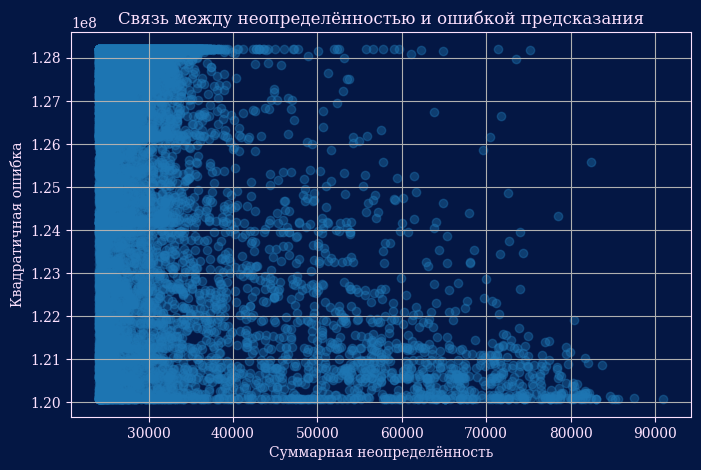

In [ ]:
import matplotlib.pyplot as plt

errors = (y_test - stakcing_mse) ** 2
total_all = aleatoric_all + epistemis_all

plt.figure(figsize=(8, 5))
plt.scatter(total_all, errors, alpha=0.4)
plt.xlabel("Суммарная неопределённость")
plt.ylabel("Квадратичная ошибка")
plt.title("Связь между неопределённостью и ошибкой предсказания")
plt.grid(True)
plt.show()

Выглядит данный график достаточно шумно

Вообще по хорошему должно быть Маленькая ошибка = низкая неопределенность. В целом при большой неопределенности ошибка по большей части уменьшается, но все равно есть отдельные экземпляры, где она большевата.

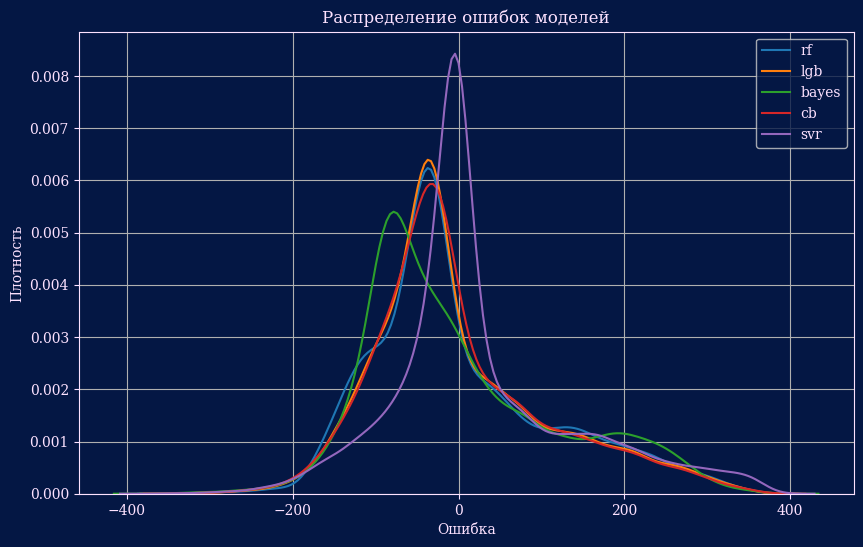

In [ ]:
model_avg_preds = np.mean(test_preds, axis=1)
df_stacking = pd.DataFrame(model_avg_preds.T, columns=list(base_models.keys()))


plt.figure(figsize=(10, 6))
for one_col in df_stacking.columns:
    sns.kdeplot(y_test - df_stacking[one_col], label=one_col)

plt.title("Распределение ошибок моделей")
plt.xlabel("Ошибка")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)
plt.show()


В целом, модели ведут себя похоже, но svr сильно отличается от других и линейная регрессия. Плохо, что много моделей похожи друг на друга, желательно чтобы ошибки были разными, но к счастью есть несколько моделей которые отличаются, что позволяет улучшить предсказания

## Сравнение результатов

In [ ]:
all_preds = []
for m_name, m_obj in base_models.items():
  pred = m_obj.predict(df_test)
  all_preds.append(pred)
separate_preds = np.array(all_preds).T

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [ ]:
base_models.keys()

dict_keys(['rf', 'lgb', 'bayes', 'cb', 'svr'])

In [ ]:
for i in range(separate_preds.shape[1]):
    mse = mean_squared_error(y_test, separate_preds[:, i])
    print(f'MSE модели: {mse}')

MSE модели: 12220.901232915443
MSE модели: 11710.067755566328
MSE модели: 13579.034954389308
MSE модели: 11521.116835604149
MSE модели: 13379.711962804415


Видно, что каждая модель дает более плохой MSE, но если делать стекинг, то получится более хороший результат => стекинг удался и наша модель работает лучше.